In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df = pd.read_csv('/content/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

print("\nData Types:\n", df.dtypes)

df.head()

Shape: (7787, 12)

Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Missing Values:
 show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

Data Types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [ ]:

df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna("0 min")

def convert_duration(x):
    if 'min' in x:
        return int(x.split()[0])
    else:
        return np.nan

df['duration_minutes'] = df['duration'].apply(convert_duration)
df['duration_minutes'] = df['duration_minutes'].fillna(df['duration_minutes'].mean())

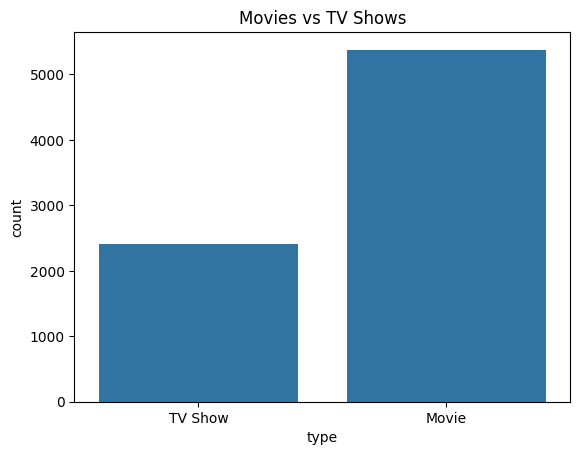

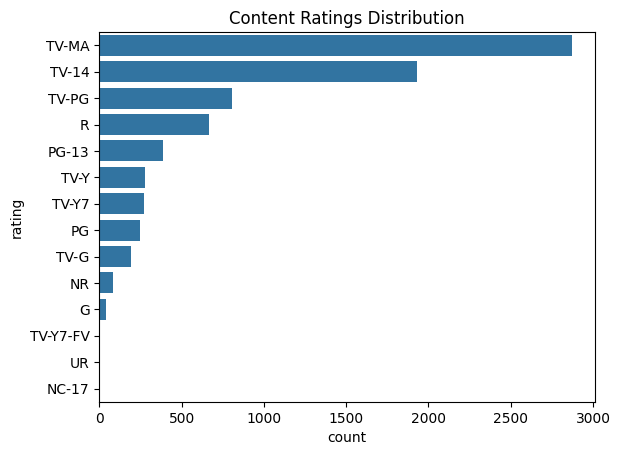

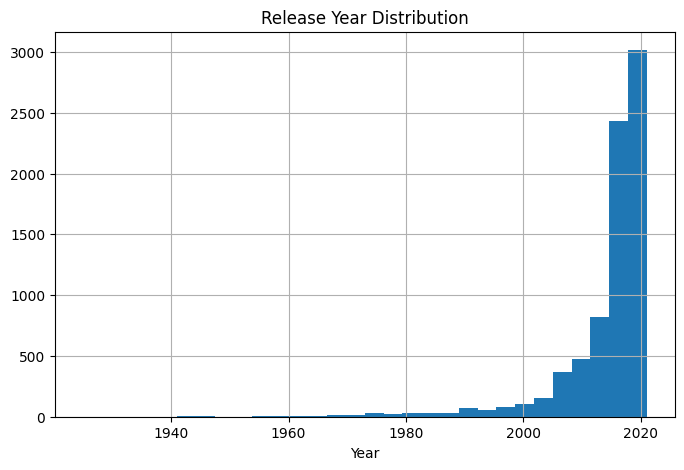

In [ ]:

sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows")
plt.show()

sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index)
plt.title("Content Ratings Distribution")
plt.show()

df['release_year'].hist(bins=30, figsize=(8,5))
plt.title("Release Year Distribution")
plt.xlabel("Year")
plt.show()

In [ ]:
df['combined_text'] = (
    df['listed_in'] + " " +
    df['description'] + " " +
    df['cast'] + " " +
    df['director']
)

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X = tfidf.fit_transform(df['combined_text'])

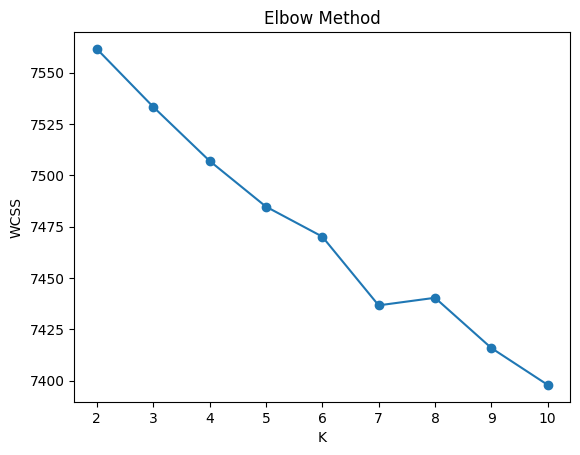

In [ ]:
wcss = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(K, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

In [ ]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"K={k} → Silhouette Score = {score}")

K=2 → Silhouette Score = 0.008782778960718286
K=3 → Silhouette Score = 0.009946169225961284
K=4 → Silhouette Score = 0.01005688601497096
K=5 → Silhouette Score = 0.007448114733330077
K=6 → Silhouette Score = 0.007685032868522594
K=7 → Silhouette Score = 0.009552168766974505
K=8 → Silhouette Score = 0.004916046913109361
K=9 → Silhouette Score = 0.006424578164870699
K=10 → Silhouette Score = 0.007251765196891146


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

df[['title','type','listed_in','cluster']].head()

,title,type,listed_in,cluster
0,3%,TV Show,"International TV Shows, TV Dramas, TV Sci-Fi &...",3
1,7:19,Movie,"Dramas, International Movies",0
2,23:59,Movie,"Horror Movies, International Movies",0
3,9,Movie,"Action & Adventure, Independent Movies, Sci-Fi...",1
4,21,Movie,Dramas,1


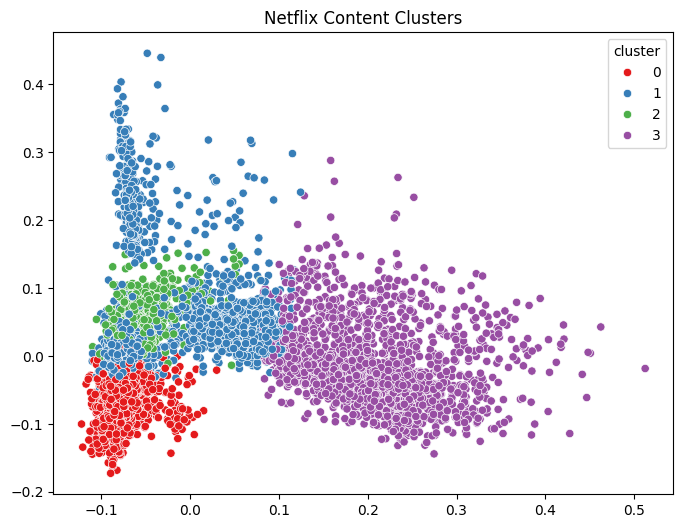

In [ ]:
pca = PCA(n_components=2)
X2 = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
sns.scatterplot(x=X2[:,0], y=X2[:,1], hue=df['cluster'], palette='Set1')
plt.title("Netflix Content Clusters")
plt.show()